In [47]:
import tensorflow as tf

import pathlib

import matplotlib.pyplot as plt

In [37]:
data_dir = pathlib.Path('/var/my-data/datasets/zenodo-8041387/main/for_training').with_suffix('')

In [42]:
img_height = 995
img_width = 1920
batch_size = 32

In [44]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


In [45]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [46]:
class_names = train_ds.class_names
print(class_names)

['legit', 'phishing']


In [49]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 995, 1920, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

2026-01-27 13:59:56.931663: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 733593600 exceeds 10% of free system memory.
2026-01-27 13:59:57.077694: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 733593600 exceeds 10% of free system memory.
2026-01-27 13:59:57.099101: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 733593728 bytes after encountering the first element of size 733593728 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-27 13:59:57.099134: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 733593728 bytes after encountering the first element of size 733593728 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-

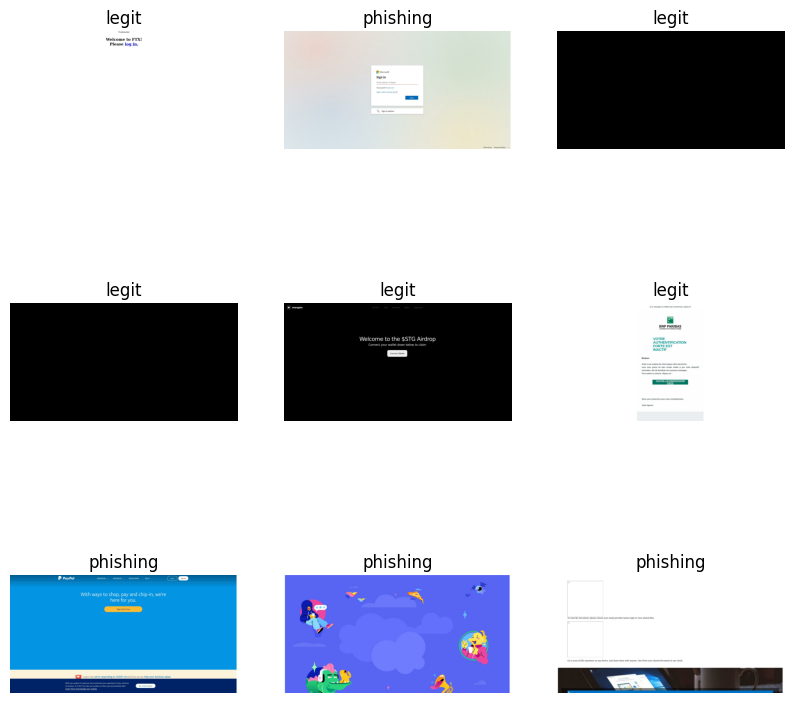

In [50]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
        

In [51]:
# continued on https://colab.research.google.com/drive/1tSwo09CnySxGJ0_1Ej04dW_JWPLkI2hP?usp=sharing